# 🤖 Fine-tune PhoBERT — Phân tích Sentiment TikTok @travinhuniversity

**Mục tiêu:** Fine-tune `vinai/phobert-base` trên 995 comment TikTok TVU được gán nhãn thủ công

**Labels:** `positive`, `neutral`, `negative`

**Thời gian ước tính:** ~20 phút (với GPU T4 trên Colab)

---
**Trước khi chạy:**
1. Vào `Runtime > Change runtime type > T4 GPU`
2. Upload file `tiktok_travinhuniversity_merged.json` vào Colab
3. Chạy từng cell theo thứ tự

## Bước 1 — Kiểm tra GPU + Cài thư viện

In [1]:
# Kiểm tra GPU
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else '❌ Không tìm thấy GPU — hãy đổi runtime!')

Wed Mar 18 23:23:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.94                 Driver Version: 560.94         CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1650      WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   45C    P0             11W /   65W |     745MiB /   4096MiB |      1%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:

# Cài thư viện cần thiết
import subprocess, sys, os

print(f'Python: {sys.executable}')

# ── Kiểm tra torch CUDA trước ────────────────────────────────────────────
try:
    import torch
    _has_cuda = torch.cuda.is_available()
    print(f'✅ torch {torch.__version__} đã có | CUDA: {_has_cuda}')
    if not _has_cuda:
        print('⚠️  torch đang là bản CPU-only → cần cài lại')
except ImportError:
    _has_cuda = False
    print('⚠️  torch chưa cài')

# ── Cài torch CUDA nếu cần ───────────────────────────────────────────────
if not _has_cuda:
    print('\n📥 Cài PyTorch CUDA 12.1 (file ~2.4GB, cần vài phút)...')
    # Dùng ổ D làm temp để tránh hết dung lượng ổ C
    os.makedirs('D:/pip_tmp', exist_ok=True)
    os.makedirs('D:/pip_cache', exist_ok=True)
    env = os.environ.copy()
    env['TMPDIR'] = 'D:/pip_tmp'
    env['TEMP']   = 'D:/pip_tmp'
    env['TMP']    = 'D:/pip_tmp'

    subprocess.run([sys.executable, '-m', 'pip', 'uninstall', '-y',
        'torch', 'torchvision', 'torchaudio'], capture_output=True)

    r = subprocess.run([sys.executable, '-m', 'pip', 'install',
        'torch', 'torchvision', 'torchaudio',
        '--index-url', 'https://download.pytorch.org/whl/cu121',
        '--cache-dir', 'D:/pip_cache',
        '--timeout', '600',
    ], env=env, capture_output=True, text=True)

    if r.returncode != 0:
        print('❌ Lỗi:\n' + r.stderr[-1500:])
    else:
        print('✅ PyTorch CUDA đã cài')
    print('\n⚠️  Restart kernel để torch CUDA có hiệu lực, rồi chạy lại từ cell này.')
else:
    print('✅ Bỏ qua — torch CUDA đã sẵn sàng')

# ── Cài các thư viện còn lại ─────────────────────────────────────────────
print('\n📥 Cài các thư viện NLP...')
r2 = subprocess.run([sys.executable, '-m', 'pip', 'install', '--upgrade',
    'huggingface_hub', 'transformers>=4.47.0', 'datasets',
    'scikit-learn', 'seaborn', 'matplotlib', 'accelerate>=0.26.0',
    'google-genai', 'ipywidgets',
], capture_output=True, text=True)

if r2.returncode != 0:
    print('❌ Lỗi:\n' + r2.stderr[-1000:])
else:
    print('✅ Xong!')

# ── Kết quả cuối ─────────────────────────────────────────────────────────
import torch
print(f'\n  torch : {torch.__version__}')
print(f'  CUDA  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'  GPU   : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM  : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
    print('\n✅ Sẵn sàng! Chạy tiếp cell tiếp theo.')
else:
    print('\n⚠️  Chưa thấy GPU — chọn đúng kernel venv rồi restart.')


Python: d:\Thuc_tap\.venv-2\Scripts\python.exe
✅ torch 2.5.1+cu121 đã có | CUDA: True
✅ Bỏ qua — torch CUDA đã sẵn sàng

📥 Cài các thư viện NLP...
✅ Xong!

  torch : 2.5.1+cu121
  CUDA  : True
  GPU   : NVIDIA GeForce GTX 1650
  VRAM  : 4.3 GB

✅ Sẵn sàng! Chạy tiếp cell tiếp theo.


In [3]:
import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠️  Đang dùng CPU — sẽ rất chậm!')

PyTorch: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce GTX 1650
VRAM: 4.3 GB


## Bước 2 — Upload file JSON

In [4]:
import os, sys, glob


def _is_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


# ====== CẤU HÌNH NGUỒN DỮ LIỆU TRAIN ======
# Đây là nơi duy nhất để thay đổi cấu hình — cell sau sẽ kế thừa
STRICT_MANUAL_ONLY = False          # False = dùng nhiều nguồn (manual + phobert)
TRAIN_SOURCES = ['manual', 'phobert']  # Nguồn nhãn được phép

DATA_PATH = None  # sẽ được gán bên dưới

if _is_colab():
    # Chạy trên Google Colab: upload từ máy tính
    from google.colab import files
    print('📁 Upload file dữ liệu (JSON/XLSX) từ máy tính...')
    uploaded = files.upload()
    if uploaded:
        DATA_PATH = list(uploaded.keys())[0]
        print(f'✅ Đã upload: {DATA_PATH}')
    else:
        raise FileNotFoundError('Không có file nào được upload!')
else:
    streamlit_file = 'data/tong_hop_comment.json'
    export_xlsx = sorted(glob.glob('data/export/comments_for_labeling_*.xlsx'))

    # Luôn ưu tiên file Streamlit (nguồn có đủ cả manual + phobert)
    if os.path.exists(streamlit_file):
        DATA_PATH = streamlit_file
        src_note = 'manual + phobert' if not STRICT_MANUAL_ONLY else 'manual-only'
        print(f'✅ Dùng file Streamlit ({src_note}): {DATA_PATH}')
    elif export_xlsx:
        DATA_PATH = export_xlsx[-1]
        print(f'✅ Ưu tiên file export mới nhất: {DATA_PATH}')
    else:
        _candidates = [
            'tong_hop_comment.json',
            'data/merged/tiktok_travinhuniversity_merged.json',
            'tiktok_travinhuniversity_merged.json',
            '../data/tong_hop_comment.json',
            os.path.join(os.path.dirname(os.getcwd()), 'tiktok_analytics', 'data', 'tong_hop_comment.json'),
            r'D:\Thuc_tap\tiktok_analytics\data\tong_hop_comment.json',
        ]
        for _p in _candidates:
            if os.path.exists(_p):
                DATA_PATH = _p
                break

    if DATA_PATH:
        print(f'✅ Tìm thấy file local: {DATA_PATH}')
    else:
        print('⚠️ Không tìm thấy file tự động. Nhập đường dẫn thủ công:')
        DATA_PATH = input('Nhập đường dẫn file dữ liệu (JSON/XLSX): ').strip().strip('"')
        if not os.path.exists(DATA_PATH):
            raise FileNotFoundError(f'File không tồn tại: {DATA_PATH}')
        print(f'✅ Đã nhận: {DATA_PATH}')

print(f'\n📄 DATA_PATH     = {DATA_PATH}')
print(f'🔒 STRICT_MANUAL = {STRICT_MANUAL_ONLY}')
print(f'📋 TRAIN_SOURCES = {TRAIN_SOURCES}')


✅ Dùng file Streamlit (manual + phobert): data/tong_hop_comment.json
✅ Tìm thấy file local: data/tong_hop_comment.json

📄 DATA_PATH     = data/tong_hop_comment.json
🔒 STRICT_MANUAL = False
📋 TRAIN_SOURCES = ['manual', 'phobert']


In [5]:
# Cách 2 (thay thế): Nếu file đã có trên Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_PATH = '/content/drive/MyDrive/tiktok_travinhuniversity_merged.json'

## Bước 3 — Tiền xử lý văn bản

In [6]:
import importlib.util
import sys
from pathlib import Path

PROJECT_ROOT = None
PREPROCESSOR_FILE = None
for candidate in [
    Path.cwd(),
    Path.cwd() / 'tiktok_analytics',
    Path(r'D:\Thuc_tap\tiktok_analytics'),
]:
    candidate_file = candidate / 'modules' / 'text_preprocessor.py'
    if candidate_file.exists():
        PROJECT_ROOT = candidate
        PREPROCESSOR_FILE = candidate_file
        break

try:
    if PREPROCESSOR_FILE is None:
        raise FileNotFoundError('Không tìm thấy modules/text_preprocessor.py')

    # Import trực tiếp từ file để tránh side-effect từ modules/__init__.py
    spec = importlib.util.spec_from_file_location('shared_text_preprocessor', str(PREPROCESSOR_FILE))
    shared_module = importlib.util.module_from_spec(spec)
    assert spec and spec.loader
    spec.loader.exec_module(shared_module)

    basic_clean_text = shared_module.basic_clean_text
    shared_preprocess = shared_module.preprocess
    print(f'✅ Dùng shared preprocessor từ: {PREPROCESSOR_FILE}')

    def preprocess_for_labeling(text: str) -> str:
        return basic_clean_text(text, remove_emojis=True)

    def preprocess_text(text: str) -> str:
        return shared_preprocess(text, normalize_teen=True, normalize_emojis=True)

except Exception as exc:
    import html
    import re
    import unicodedata

    print(f'⚠️ Không import được shared preprocessor ({exc}) -> dùng fallback trong notebook.')

    TEENCODE = {
        'k': 'không', 'ko': 'không', 'kh': 'không', 'khong': 'không',
        'đc': 'được', 'dc': 'được', 'đk': 'được',
        'mn': 'mọi người', 'mng': 'mọi người', 'mk': 'mình',
        'sv': 'sinh viên', 'hs': 'học sinh', 'gv': 'giáo viên',
        'tvu': 'trường đại học trà vinh', 'ktx': 'ký túc xá', 'hp': 'học phí',
        'nt': 'nhắn tin', 'ib': 'nhắn tin', 'pm': 'nhắn tin',
        'cx': 'cũng', 'cg': 'cũng', 'ntn': 'như thế nào',
        'tks': 'cảm ơn', 'thks': 'cảm ơn', 'ty': 'cảm ơn',
        'ok': 'ổn', 'oke': 'ổn', 'okey': 'ổn',
        'r': 'rồi', 'rùi': 'rồi', 'j': 'gì', 'z': 'vậy', 'v': 'vậy', 'vs': 'với',
        'g': 'gì', 'tg': 'thời gian', 'h': 'giờ', 'ms': 'mới', 'ns': 'nói', 'ngta': 'người ta',
        'tui': 'tôi', 'mik': 'mình', 'bn': 'bạn', 'bh': 'bao giờ', 'dag': 'đang', 'đag': 'đang',
    }

    EMOJI_MAP = {
        '😭': ' rất buồn ', '😢': ' buồn ', '😔': ' buồn ',
        '😡': ' tức giận ', '😤': ' bực bội ', '👎': ' không tốt ',
        '😍': ' rất thích ', '❤️': ' yêu thích ', '🥰': ' yêu quý ',
        '😊': ' vui ', '😄': ' rất vui ', '🤩': ' tuyệt vời ',
        '🔥': ' tuyệt ', '👏': ' khen ngợi ', '🎉': ' chúc mừng ',
        '👍': ' tốt ', '✅': ' đồng ý ', '💪': ' cố lên ',
        '🙏': ' cảm ơn ', '💯': ' hoàn hảo ', '⭐': ' tốt ',
        '😂': ' hài hước ', '🤣': ' buồn cười ', '😅': ' ngại ',
    }

    _URL_RE = re.compile(r'(?:https?://|www\.)\S+', re.IGNORECASE)
    _MENTION_RE = re.compile(r'(?<!\w)@[A-Za-z0-9._]+')
    _HASHTAG_RE = re.compile(r'#([\w_]+)', re.UNICODE)
    _ZERO_WIDTH_RE = re.compile(r'[\u200b\u200c\u200d\u200e\u200f\ufeff]')
    _MODEL_SPECIAL_RE = re.compile(
        r'[^\w\sàáâãèéêìíòóôõùúýăđơưạảấầẩẫậắặẳẵặẹẻẽếềểễệỉịọỏốồổỗộớờởỡợụủứừửữựỳỷỹỵ'
        r'ÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚÝĂĐƠƯ]',
        re.UNICODE,
    )
    _BASIC_SPECIAL_RE = re.compile(
        r'[^\w\sàáâãèéêìíòóôõùúýăđơưạảấầẩẫậắặẳẵặẹẻẽếềểễệỉịọỏốồổỗộớờởỡợụủứừửữựỳỷỹỵ'
        r'ÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚÝĂĐƠƯ!?.,:;\-/]',
        re.UNICODE,
    )

    def _normalize_whitespace(text: str) -> str:
        return re.sub(r'\s+', ' ', text).strip()

    def preprocess_for_labeling(text: str) -> str:
        text = html.unescape(str(text or ''))
        text = unicodedata.normalize('NFC', text)
        text = _ZERO_WIDTH_RE.sub(' ', text)
        text = _URL_RE.sub(' ', text)
        text = _MENTION_RE.sub(' ', text)
        text = _HASHTAG_RE.sub(r' \1 ', text)
        for emoji in EMOJI_MAP:
            text = text.replace(emoji, ' ')
        text = re.sub(r'(.)\1{2,}', r'\1\1', text)
        text = _BASIC_SPECIAL_RE.sub(' ', text)
        return _normalize_whitespace(text)

    def preprocess_text(text: str) -> str:
        text = preprocess_for_labeling(text).lower()
        for emoji, replacement in EMOJI_MAP.items():
            text = text.replace(emoji, replacement)
        tokens = text.split()
        tokens = [TEENCODE.get(t, t) for t in tokens]
        text = ' '.join(tokens)
        text = _MODEL_SPECIAL_RE.sub(' ', text)
        return _normalize_whitespace(text)

test_cases = [
    '  @travinhuniversity  trường này ổn k ạ???  ',
    'ib mình nhaaa 😭😭 link đây https://t.co/demo',
    '#TVU học phí sao mn ơi 🔥',
    'sv TVU cảm ơn @admin 🙏',
]
for t in test_cases:
    print(f'IN   : {t}')
    print(f'LABEL: {preprocess_for_labeling(t)}')
    print(f'MODEL: {preprocess_text(t)}')
    print()

✅ Dùng shared preprocessor từ: d:\Thuc_tap\tiktok_analytics\modules\text_preprocessor.py
IN   :   @travinhuniversity  trường này ổn k ạ???  
LABEL: trường này ổn k ạ??
MODEL: trường này ổn không ạ

IN   : ib mình nhaaa 😭😭 link đây https://t.co/demo
LABEL: ib mình nhaa link đây
MODEL: inbox mình nhaa link đây

IN   : #TVU học phí sao mn ơi 🔥
LABEL: TVU học phí sao mn ơi
MODEL: trường đại học trà vinh học phí sao mọi người ơi

IN   : sv TVU cảm ơn @admin 🙏
LABEL: sv TVU cảm ơn
MODEL: sinh viên trường đại học trà vinh cảm ơn



In [7]:
# Load data từ JSON/XLSX (manual-first)
import json
import pandas as pd
import os

# ====== CẤU HÌNH NGUỒN DỮ LIỆU TRAIN ======
# STRICT_MANUAL_ONLY = True  => chỉ dùng nhãn thủ công (manual)
# STRICT_MANUAL_ONLY = False + TRAIN_SOURCES => dùng nhiều nguồn
STRICT_MANUAL_ONLY = False      # Tắt để train trên cả manual + phobert
TRAIN_SOURCES = ['manual', 'phobert']  # Nguồn nhãn được phép: 'manual', 'phobert', 'gemini'

# Kiểm tra lại DATA_PATH
_need_search = 'DATA_PATH' not in dir() or DATA_PATH is None or not os.path.exists(DATA_PATH)

if _need_search:
    _xlsx = sorted([p for p in [
        'data/export/comments_for_labeling_20260313_095319.xlsx',
        'comments_for_labeling_20260313_095319.xlsx',
    ] if os.path.exists(p)])

    if _xlsx:
        DATA_PATH = _xlsx[-1]
        print(f'✅ Tìm thấy file export: {DATA_PATH}')
    else:
        # fallback nhưng vẫn ưu tiên file đã chỉnh nhãn từ Streamlit
        _candidates = [
            'data/tong_hop_comment.json',
            'tong_hop_comment.json',
            'data/merged/tiktok_travinhuniversity_merged.json',
            'tiktok_travinhuniversity_merged.json',
            r'D:\Thuc_tap\tiktok_analytics\data\tong_hop_comment.json',
        ]
        DATA_PATH = None
        for _p in _candidates:
            if os.path.exists(_p):
                DATA_PATH = _p
                print(f'✅ Tìm thấy: {DATA_PATH}')
                break

    if DATA_PATH is None:
        DATA_PATH = input('⚠️ Nhập đường dẫn file dữ liệu (JSON/XLSX): ').strip().strip('"')
        if not os.path.exists(DATA_PATH):
            raise FileNotFoundError(f'File không tồn tại: {DATA_PATH}')

print(f'📄 DATA_PATH = {DATA_PATH}')

ext = os.path.splitext(DATA_PATH)[1].lower()

if ext in ['.xlsx', '.xls']:
    df = pd.read_excel(DATA_PATH)
    print(f'Đã đọc Excel: {len(df)} dòng')

    if 'text' not in df.columns:
        raise ValueError(f'File Excel thiếu cột text. Cột hiện có: {df.columns.tolist()}')

    # Ưu tiên nhãn thủ công; không fallback sang pseudo khi strict mode bật
    label_col = None
    label_source = None

    if 'manual_sentiment' in df.columns and df['manual_sentiment'].notna().sum() > 0:
        label_col = 'manual_sentiment'
        label_source = 'manual_sentiment'
    elif 'sentiment' in df.columns and df['sentiment'].notna().sum() > 0:
        label_col = 'sentiment'
        label_source = 'sentiment'
    elif not STRICT_MANUAL_ONLY and 'phobert_sentiment' in df.columns and df['phobert_sentiment'].notna().sum() > 0:
        label_col = 'phobert_sentiment'
        label_source = 'phobert_sentiment'

    if label_col is None:
        if STRICT_MANUAL_ONLY:
            raise ValueError(
                'STRICT_MANUAL_ONLY=True: Excel chưa có nhãn thủ công. '
                'Hãy điền manual_sentiment hoặc dùng data/tong_hop_comment.json.'
            )
        raise ValueError('Không tìm thấy cột nhãn hợp lệ (manual_sentiment/sentiment/phobert_sentiment).')

    df['sentiment'] = df[label_col].astype(str).str.strip().str.lower()
    df['method'] = 'manual' if label_source in ['manual_sentiment', 'sentiment'] else 'pseudo'

    comments = df.to_dict(orient='records')
    raw = {
        'comments': comments,
        'total_comments': len(comments),
        'label_source': label_source,
        'strict_manual_only': STRICT_MANUAL_ONLY,
    }
    data_shape = f'excel.rows (label={label_source})'

else:
    with open(DATA_PATH, encoding='utf-8') as f:
        raw = json.load(f)

    if isinstance(raw.get('comments'), list):
        comments = raw.get('comments', [])
        data_shape = 'flat.comments'
    elif isinstance(raw.get('videos'), list):
        comments = []
        for v in raw.get('videos', []):
            comments.extend(v.get('comments', []))
        data_shape = 'nested.videos.comments'
    else:
        comments = []
        data_shape = 'unknown'

    df = pd.DataFrame(comments)

print(f'Data shape: {data_shape}')
print(f'Tổng số comment load được: {len(comments)}')
if isinstance(raw, dict) and 'total_comments' in raw:
    print(f'total_comments trong metadata: {raw.get("total_comments")}')

if 'sentiment' in df.columns:
    df['sentiment'] = df['sentiment'].astype(str).str.strip().str.lower()

print('Cột:', df.columns.tolist())

if 'method' in df.columns:
    print('\nPhân phối method:', df['method'].value_counts(dropna=False).to_dict())
if 'sentiment' in df.columns:
    print('Phân phối sentiment:', df['sentiment'].value_counts(dropna=False).to_dict())

if ext in ['.xlsx', '.xls']:
    print(f'✅ Đang train từ nhãn Excel: {raw.get("label_source")}')
elif os.path.normpath(DATA_PATH).endswith(os.path.normpath('data/tong_hop_comment.json')):
    print('✅ ĐANG TRAIN TỪ FILE STREAMLIT: data/tong_hop_comment.json')
else:
    print('ℹ️ Đang train từ nguồn khác, kiểm tra DATA_PATH nếu cần.')

print(f'🔒 STRICT_MANUAL_ONLY = {STRICT_MANUAL_ONLY}')
print(f'📋 TRAIN_SOURCES      = {globals().get("TRAIN_SOURCES", "N/A")}')


📄 DATA_PATH = data/tong_hop_comment.json
Data shape: nested.videos.comments
Tổng số comment load được: 2865
total_comments trong metadata: 2865
Cột: ['text', 'author', 'likes', 'video_id', 'video_url', 'created_at', 'sentiment', 'confidence', 'language', 'method', 'cid']

Phân phối method: {'manual': 2004, 'phobert': 778, nan: 83}
Phân phối sentiment: {'neutral': 1678, 'positive': 941, 'negative': 246}
✅ ĐANG TRAIN TỪ FILE STREAMLIT: data/tong_hop_comment.json
🔒 STRICT_MANUAL_ONLY = False
📋 TRAIN_SOURCES      = ['manual', 'phobert']


In [8]:
# Override cấu hình cho lần train manual-only (2004)
import os

STRICT_MANUAL_ONLY = True
TRAIN_SOURCES = ['manual']
DATA_PATH = 'data/export/retrain_manual_only_2004.json'

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f'Không tìm thấy {DATA_PATH}. Hãy chạy: python prepare_retrain_datasets.py'
    )

print('✅ MANUAL-ONLY MODE đã bật')
print(f'📄 DATA_PATH = {DATA_PATH}')
print(f'🔒 STRICT_MANUAL_ONLY = {STRICT_MANUAL_ONLY}')
print(f'📋 TRAIN_SOURCES = {TRAIN_SOURCES}')

✅ MANUAL-ONLY MODE đã bật
📄 DATA_PATH = data/export/retrain_manual_only_2004.json
🔒 STRICT_MANUAL_ONLY = True
📋 TRAIN_SOURCES = ['manual']


In [9]:
# Lọc dữ liệu đã có sentiment hợp lệ (theo TRAIN_SOURCES)
LABEL_MAP = {'positive': 0, 'neutral': 1, 'negative': 2}

_required_cols = {'text', 'sentiment'}
_missing_cols = [c for c in _required_cols if c not in df.columns]
if _missing_cols:
    raise ValueError(f'Thiếu cột bắt buộc: {_missing_cols}')

before_count = len(df)

_SOURCES = globals().get('TRAIN_SOURCES', None)

if 'STRICT_MANUAL_ONLY' in globals() and STRICT_MANUAL_ONLY and 'method' in df.columns:
    df_work = df[df['method'].astype(str).str.lower().eq('manual')].copy()
    print(f'🔒 Lọc manual-only: {len(df_work)}/{before_count} comment')
elif _SOURCES and 'method' in df.columns:
    _source_set = [s.strip().lower() for s in _SOURCES]
    df_work = df[df['method'].astype(str).str.lower().isin(_source_set)].copy()
    print(f'✅ Lọc theo TRAIN_SOURCES={_SOURCES}: {len(df_work)}/{before_count} comment')
else:
    df_work = df.copy()
    print(f'ℹ️ Không giới hạn nguồn: dùng tất cả {before_count} comment')

df_labeled = df_work[df_work['sentiment'].isin(LABEL_MAP.keys())].copy()

# Tiền xử lý text nhưng KHÔNG loại bỏ comment ngắn
df_labeled['text_clean'] = df_labeled['text'].astype(str).apply(preprocess_text)

# Fallback nếu preprocess tạo rỗng: dùng text gốc (đã strip) để giữ dữ liệu
_empty_mask = df_labeled['text_clean'].str.len() == 0
df_labeled.loc[_empty_mask, 'text_clean'] = df_labeled.loc[_empty_mask, 'text'].astype(str).str.strip()

# Gán nhãn số
df_labeled['label'] = df_labeled['sentiment'].map(LABEL_MAP)

after_count = len(df_labeled)
print(f'Số lượng trước lọc: {before_count}')
print(f'Sau lọc nguồn + sentiment hợp lệ: {after_count}')

if 'method' in df_labeled.columns:
    method_dist = df_labeled['method'].value_counts(dropna=False).to_dict()
    print(f'Phân phối method sau lọc: {method_dist}')

if after_count == 0:
    raise ValueError('Không có dữ liệu hợp lệ để train. Kiểm tra TRAIN_SOURCES và nguồn nhãn.')

print('\nPhân phối sentiment:')
for sent, count in df_labeled['sentiment'].value_counts().items():
    pct = count / len(df_labeled) * 100
    print(f'  {sent:10s}: {count:4d} ({pct:.1f}%)')

print('\nVí dụ:')
for row in df_labeled[['text', 'text_clean', 'sentiment']].sample(min(3, len(df_labeled))).itertuples():
    print(f'  [{row.sentiment}] {row.text[:50]} -> {row.text_clean[:50]}')


🔒 Lọc manual-only: 2004/2865 comment
Số lượng trước lọc: 2865
Sau lọc nguồn + sentiment hợp lệ: 2004
Phân phối method sau lọc: {'manual': 2004}

Phân phối sentiment:
  neutral   : 1080 (53.9%)
  positive  :  744 (37.1%)
  negative  :  180 (9.0%)

Ví dụ:
  [neutral] ngành công nghệ kỉ thuật điều khiển và tự động hóa -> ngành công nghệ kỉ thuật điều khiển và tự động hóa
  [neutral] Ik hỗ trợ tuyển sinh của trường 🥰 -> Ik hỗ trợ tuyển sinh của trường
  [positive] 🥰🥰🥰 -> 🥰🥰🥰


## Bước 4 — Chia train/val/test

In [10]:
from sklearn.model_selection import train_test_split
import collections

# ===== Fixed split settings =====
RANDOM_STATE = 42

# Chia 70/15/15 với stratify để giữ tỷ lệ class
X = df_labeled['text_clean'].values
y = df_labeled['label'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')
print(f'Random state fixed: {RANDOM_STATE}')

ID2LABEL = {0: 'positive', 1: 'neutral', 2: 'negative'}
split_dist = {}
for split_name, labels in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    cnt = collections.Counter(labels)
    named = {ID2LABEL[k]: v for k, v in sorted(cnt.items())}
    split_dist[split_name] = named
    print(f'  {split_name}: ' + ', '.join(f'{k}={v}' for k, v in named.items()))

# ===== Sanity check before training =====
test_support = split_dist['Test']
if 'EXPECTED_TEST_SUPPORT' in globals() and EXPECTED_TEST_SUPPORT != test_support:
    print(
        '⚠️ Test support thay đổi do dữ liệu gán nhãn đã cập nhật: '
        f'old={EXPECTED_TEST_SUPPORT} -> new={test_support}. '
        'Không so sánh trực tiếp metric với run cũ khác support.'
    )
EXPECTED_TEST_SUPPORT = test_support

print('✅ SANITY CHECK PASSED: test support đã đồng bộ với dữ liệu hiện tại.')

Train: 1402 | Val: 301 | Test: 301
Random state fixed: 42
  Train: positive=520, neutral=756, negative=126
  Val: positive=112, neutral=162, negative=27
  Test: positive=112, neutral=162, negative=27
✅ SANITY CHECK PASSED: test support đã đồng bộ với dữ liệu hiện tại.


## Bước 4.4 — Tắt tạo synthetic data

- Luồng tạo comment giả bằng Gemini/rule-based đã được vô hiệu hóa.
- Notebook chỉ dùng dữ liệu thật đã gán nhãn để train.

In [11]:
# Synthetic generation đã tắt để đảm bảo train chỉ dùng dữ liệu thật
USE_GEMINI = False
FALLBACK_TO_RULE_BASED = False
N_AUG_PER_SAMPLE = 0

print('⛔ Synthetic data generation is DISABLED for this notebook run.')
print('✅ Chỉ dùng dữ liệu thật đã gán nhãn (manual) để train.')

⛔ Synthetic data generation is DISABLED for this notebook run.
✅ Chỉ dùng dữ liệu thật đã gán nhãn (manual) để train.


## Bước 4.5 — Kiểm tra split train/val/test (không augment)

- Không nối dữ liệu synthetic vào train.
- `train/val/test` đều lấy từ dữ liệu thật đã gán nhãn.

In [12]:
# Sanity check split (không augment synthetic)
import os
import re
import json
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import collections
from sklearn.model_selection import train_test_split

AUGMENT_NEGATIVE_ENABLED = False
AUGMENT_METHOD_NAME = 'augmented'

if 'LABEL_MAP' not in globals():
    LABEL_MAP = {'positive': 0, 'neutral': 1, 'negative': 2}
if 'ID2LABEL' not in globals():
    ID2LABEL = {0: 'positive', 1: 'neutral', 2: 'negative'}
if 'RANDOM_STATE' not in globals():
    RANDOM_STATE = 42
if 'STRICT_MANUAL_ONLY' not in globals():
    STRICT_MANUAL_ONLY = True

# Fallback tối thiểu nếu kernel vừa restart và chưa có hàm preprocess từ các cell trước
if 'preprocess_text' not in globals():
    try:
        for _cand in [
            Path.cwd(),
            Path.cwd() / 'tiktok_analytics',
            Path(r'D:\Thuc_tap\tiktok_analytics'),
        ]:
            if (_cand / 'modules' / 'text_preprocessor.py').exists():
                if str(_cand) not in sys.path:
                    sys.path.insert(0, str(_cand))
                break
        from modules.text_preprocessor import preprocess as shared_preprocess

        def preprocess_text(text: str) -> str:
            return shared_preprocess(text, normalize_teen=True, normalize_emojis=True)
    except Exception:
        def preprocess_text(text: str) -> str:
            text = str(text or '').strip().lower()
            text = re.sub(r'\s+', ' ', text)
            return text

# Nếu chưa có df_labeled trong kernel thì tự load lại nguồn dữ liệu và dựng nhãn
if 'df_labeled' not in globals():
    candidate_paths = []
    if 'DATA_PATH' in globals() and DATA_PATH:
        candidate_paths.append(DATA_PATH)
    candidate_paths.extend([
        'data/tong_hop_comment.json',
        'tong_hop_comment.json',
        'data/export/comments_for_labeling_20260313_095319.xlsx',
        'comments_for_labeling_20260313_095319.xlsx',
    ])

    resolved_path = next((p for p in candidate_paths if os.path.exists(p)), None)
    if resolved_path is None:
        raise RuntimeError(
            'Không tìm thấy nguồn dữ liệu để dựng lại df_labeled. Hãy chạy lại các cell load data trước.'
        )

    ext = os.path.splitext(resolved_path)[1].lower()
    if ext in ['.xlsx', '.xls']:
        _df = pd.read_excel(resolved_path)
        if 'text' not in _df.columns:
            raise ValueError(f'File Excel thiếu cột text: {resolved_path}')

        label_col = None
        if 'manual_sentiment' in _df.columns and _df['manual_sentiment'].notna().sum() > 0:
            label_col = 'manual_sentiment'
        elif 'sentiment' in _df.columns and _df['sentiment'].notna().sum() > 0:
            label_col = 'sentiment'
        elif (not STRICT_MANUAL_ONLY) and 'phobert_sentiment' in _df.columns and _df['phobert_sentiment'].notna().sum() > 0:
            label_col = 'phobert_sentiment'

        if label_col is None:
            raise ValueError('Không tìm thấy cột nhãn hợp lệ để dựng df_labeled từ Excel.')

        _df['sentiment'] = _df[label_col].astype(str).str.strip().str.lower()
        if 'method' not in _df.columns:
            _df['method'] = 'manual' if label_col in ['manual_sentiment', 'sentiment'] else 'pseudo'
        df = _df.copy()
    else:
        with open(resolved_path, encoding='utf-8') as f:
            raw = json.load(f)
        if isinstance(raw, dict) and isinstance(raw.get('comments'), list):
            comments = raw['comments']
        elif isinstance(raw, dict) and isinstance(raw.get('videos'), list):
            comments = []
            for v in raw['videos']:
                comments.extend(v.get('comments', []))
        elif isinstance(raw, list):
            comments = raw
        else:
            raise ValueError(f'Cấu trúc dữ liệu không hỗ trợ: {resolved_path}')
        df = pd.DataFrame(comments)

    if 'sentiment' not in df.columns or 'text' not in df.columns:
        raise ValueError('Không thể dựng df_labeled vì thiếu cột text/sentiment.')

    df['sentiment'] = df['sentiment'].astype(str).str.strip().str.lower()
    if 'method' in df.columns and STRICT_MANUAL_ONLY:
        df_work = df[df['method'].astype(str).str.lower().eq('manual')].copy()
    else:
        df_work = df.copy()

    df_labeled = df_work[df_work['sentiment'].isin(LABEL_MAP.keys())].copy()
    df_labeled['text_clean'] = df_labeled['text'].astype(str).apply(preprocess_text)
    _empty_mask = df_labeled['text_clean'].str.len() == 0
    df_labeled.loc[_empty_mask, 'text_clean'] = df_labeled.loc[_empty_mask, 'text'].astype(str).str.strip()
    df_labeled['label'] = df_labeled['sentiment'].map(LABEL_MAP)
    print(f'ℹ️ Đã tự dựng lại df_labeled từ: {resolved_path} | rows={len(df_labeled)}')

# Nếu chưa có split trong kernel hiện tại thì tự dựng lại đúng cấu hình chuẩn
_split_vars_ready = all(name in globals() for name in ['X_train', 'X_val', 'X_test', 'y_train', 'y_val', 'y_test'])
if not _split_vars_ready:
    X = df_labeled['text_clean'].values
    y = df_labeled['label'].values

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
    )

    _test_cnt = collections.Counter(y_test)
    _test_support = {ID2LABEL[k]: v for k, v in sorted(_test_cnt.items())}
    if 'EXPECTED_TEST_SUPPORT' in globals() and EXPECTED_TEST_SUPPORT != _test_support:
        print(
            '⚠️ Test support đã thay đổi sau khi thêm nhãn mới: '
            f'old={EXPECTED_TEST_SUPPORT} -> new={_test_support}'
        )
    EXPECTED_TEST_SUPPORT = _test_support
    print('ℹ️ Chưa có split trong kernel -> đã tự dựng lại X_train/X_val/X_test theo cấu hình chuẩn.')

print('⛔ Synthetic augmentation: DISABLED')
print('✅ Train/Val/Test chỉ dùng dữ liệu thật đã gán nhãn.')

train_cnt = collections.Counter(y_train)
val_cnt = collections.Counter(y_val)
test_cnt = collections.Counter(y_test)
print('\n📊 Label distribution (no augmentation):')
print('  Train:', {ID2LABEL[k]: int(v) for k, v in sorted(train_cnt.items())})
print('  Val  :', {ID2LABEL[k]: int(v) for k, v in sorted(val_cnt.items())})
print('  Test :', {ID2LABEL[k]: int(v) for k, v in sorted(test_cnt.items())})

if AUGMENT_NEGATIVE_ENABLED:
    raise RuntimeError('AUGMENT_NEGATIVE_ENABLED phải = False trong chế độ no-synthetic.')

⛔ Synthetic augmentation: DISABLED
✅ Train/Val/Test chỉ dùng dữ liệu thật đã gán nhãn.

📊 Label distribution (no augmentation):
  Train: {'positive': 520, 'neutral': 756, 'negative': 126}
  Val  : {'positive': 112, 'neutral': 162, 'negative': 27}
  Test : {'positive': 112, 'neutral': 162, 'negative': 27}


## Bước 5 — Tokenize PhoBERT

In [13]:
from transformers import AutoTokenizer
import torch
from torch.utils.data import Dataset, DataLoader

MODEL_NAME = 'vinai/phobert-base'  # PhoBERT base tiếng Việt
MAX_LEN = 96  # Giảm từ 128 -> 96 để tiết kiệm VRAM trên GPU 4GB

print(f'📥 Tải tokenizer {MODEL_NAME}...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print('✅ Tokenizer sẵn sàng')

# Test tokenize
sample = X_train[0]
enc = tokenizer(sample, truncation=True, max_length=MAX_LEN, padding='max_length', return_tensors='pt')
print(f'\nVí dụ: "{sample[:50]}"')
print(f'Input IDs shape: {enc["input_ids"].shape}')
print(f'Tokens: {tokenizer.convert_ids_to_tokens(enc["input_ids"][0][:15])}')

📥 Tải tokenizer vinai/phobert-base...


✅ Tokenizer sẵn sàng

Ví dụ: "Tấm hình hồi 2017 Khu 2"
Input IDs shape: torch.Size([1, 96])
Tokens: ['<s>', 'Tấm', 'hình', 'hồi', '2017', 'Khu', '2', '</s>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']


In [14]:
class TikTokDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# GTX 1650 (4GB VRAM): giảm micro-batch để tránh OOM
BATCH_SIZE = 4
GRAD_ACCUM = 4  # effective batch vẫn = 16

# Chọn profile cân bằng lớp: overall_reliable | negative_recall
IMBALANCE_PROFILE = 'overall_reliable'

if IMBALANCE_PROFILE == 'negative_recall':
    BALANCED_TRAIN_SAMPLING = True
    NEGATIVE_SAMPLER_BOOST = 1.25
else:
    BALANCED_TRAIN_SAMPLING = False
    NEGATIVE_SAMPLER_BOOST = 1.00

train_dataset = TikTokDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = TikTokDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = TikTokDataset(X_test,  y_test,  tokenizer, MAX_LEN)

# num_workers=0 bắt buộc trên Windows để tránh crash/hang
if BALANCED_TRAIN_SAMPLING:
    import numpy as np
    from torch.utils.data import WeightedRandomSampler

    y_train_np = np.asarray(y_train, dtype=np.int64)
    class_counts = np.bincount(y_train_np, minlength=3)
    class_weights_sampler = 1.0 / np.maximum(class_counts, 1)
    class_weights_sampler[2] *= NEGATIVE_SAMPLER_BOOST
    sample_weights = class_weights_sampler[y_train_np]
    train_sampler = WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True,
    )
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        sampler=train_sampler,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
    )
    print(f'✅ Imbalance profile: {IMBALANCE_PROFILE} (balanced sampler ON)')
    print(
        f'   Train class counts: pos={class_counts[0]}, neu={class_counts[1]}, neg={class_counts[2]} | '
        f'negative sampler boost={NEGATIVE_SAMPLER_BOOST}'
    )
else:
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        pin_memory=False,
    )
    print(f'✅ Imbalance profile: {IMBALANCE_PROFILE} (balanced sampler OFF)')

val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print(f'✅ Datasets: train={len(train_dataset)}, val={len(val_dataset)}, test={len(test_dataset)}')
print(f'✅ Batch size: {BATCH_SIZE} (gradient accumulation x{GRAD_ACCUM} -> effective batch {BATCH_SIZE*GRAD_ACCUM})')
print(f'✅ Train batches per epoch: {len(train_loader)}')

✅ Imbalance profile: overall_reliable (balanced sampler OFF)
✅ Datasets: train=1402, val=301, test=301
✅ Batch size: 4 (gradient accumulation x4 -> effective batch 16)
✅ Train batches per epoch: 351


## Bước 6 — Fine-tune PhoBERT (~15-20 phút)

In [15]:
from transformers import AutoModelForSequenceClassification, AutoConfig
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
import numpy as np
import random

# Preset cấu hình để chạy lại nhanh và ổn định hơn
TRAIN_PRESET = "negative_focus"  # chọn: stable | negative_focus

PRESET_CFG = {
    "stable": {
        "EPOCHS": 6,
        "LR": 2e-5,
        "PATIENCE": 2,
        "WARMUP_RATIO": 0.10,
        "LABEL_SMOOTHING": 0.05,
        "WEIGHT_EXP": 0.50,
    },
    "negative_focus": {
        "EPOCHS": 8,
        "LR": 1.5e-5,
        "PATIENCE": 3,
        "WARMUP_RATIO": 0.12,
        "LABEL_SMOOTHING": 0.03,
        "WEIGHT_EXP": 0.70,
    },
}

cfg = PRESET_CFG[TRAIN_PRESET]

# Seed cố định để kết quả bớt dao động
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

NUM_LABELS  = 3
EPOCHS      = cfg["EPOCHS"]
LR          = cfg["LR"]
PATIENCE    = cfg["PATIENCE"]
WARMUP_RATIO = cfg["WARMUP_RATIO"]
LABEL_SMOOTHING = cfg["LABEL_SMOOTHING"]
WEIGHT_EXP = cfg["WEIGHT_EXP"]

# Boost loss theo profile imbalance đã chọn ở cell DataLoader
if 'IMBALANCE_PROFILE' not in globals():
    IMBALANCE_PROFILE = 'overall_reliable'
NEGATIVE_LOSS_BOOST = 1.0 if IMBALANCE_PROFILE == 'overall_reliable' else 1.20

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'Preset: {TRAIN_PRESET} | Seed: {SEED}')
print(f'Imbalance profile: {IMBALANCE_PROFILE} | NEGATIVE_LOSS_BOOST={NEGATIVE_LOSS_BOOST}')

# Tính class weights để xử lý imbalance
from sklearn.utils.class_weight import compute_class_weight
base_weights = compute_class_weight('balanced', classes=np.array([0,1,2]), y=y_train)
class_weights = np.power(base_weights, WEIGHT_EXP)
class_weights[2] = class_weights[2] * NEGATIVE_LOSS_BOOST
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
print(f'Class weights(raw): pos={base_weights[0]:.2f}, neu={base_weights[1]:.2f}, neg={base_weights[2]:.2f}')
print(
    f'Class weights(use): pos={class_weights[0]:.2f}, neu={class_weights[1]:.2f}, '
    f'neg={class_weights[2]:.2f} (negative boost x{NEGATIVE_LOSS_BOOST})'
 )

# Tải model (vinai/phobert-base chỉ có pytorch_model.bin)
print(f'\n📥 Tải model {MODEL_NAME}...')
from huggingface_hub import hf_hub_download

_label_kwargs = dict(
    num_labels=NUM_LABELS,
    id2label={0: 'positive', 1: 'neutral', 2: 'negative'},
    label2id={'positive': 0, 'neutral': 1, 'negative': 2},
)
_bin_path   = hf_hub_download(MODEL_NAME, 'pytorch_model.bin')
_config     = AutoConfig.from_pretrained(MODEL_NAME, **_label_kwargs)
model       = AutoModelForSequenceClassification.from_config(_config)
_state_dict = torch.load(_bin_path, map_location='cpu', weights_only=False)
model.load_state_dict(_state_dict, strict=False)
del _state_dict
model = model.to(DEVICE)
print(f'✅ Model loaded | Params: {sum(p.numel() for p in model.parameters()):,}')

# Optimizer + scheduler
# foreach=False giảm peak memory ở optimizer.step() trên GPU VRAM thấp
optimizer   = AdamW(model.parameters(), lr=LR, weight_decay=0.01, foreach=False)
total_steps = len(train_loader) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(total_steps * WARMUP_RATIO),
    num_training_steps=total_steps
)

# Loss với class weights + label smoothing
loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=LABEL_SMOOTHING)
print(
    f'\nConfig: preset={TRAIN_PRESET} | LR={LR} | Epochs={EPOCHS} | '
    f'Warmup={int(total_steps*WARMUP_RATIO)} steps | Label smoothing={LABEL_SMOOTHING} | '
    f'Early stopping patience={PATIENCE}'
)
print('🔧 OOM guard: MAX_LEN=96, BATCH_SIZE=4, GRAD_ACCUM=4, AdamW(foreach=False)')

Device: cuda
Preset: negative_focus | Seed: 42
Imbalance profile: overall_reliable | NEGATIVE_LOSS_BOOST=1.0
Class weights(raw): pos=0.90, neu=0.62, neg=3.71
Class weights(use): pos=0.93, neu=0.71, neg=2.50 (negative boost x1.0)

📥 Tải model vinai/phobert-base...
✅ Model loaded | Params: 135,000,579

Config: preset=negative_focus | LR=1.5e-05 | Epochs=8 | Warmup=336 steps | Label smoothing=0.03 | Early stopping patience=3
🔧 OOM guard: MAX_LEN=96, BATCH_SIZE=4, GRAD_ACCUM=4, AdamW(foreach=False)


In [16]:
from sklearn.metrics import f1_score, accuracy_score

def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels         = batch['label'].to(DEVICE)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, labels)
            total_loss += loss.item()
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1_weighted = f1_score(all_labels, all_preds, average='weighted')
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    return total_loss / len(loader), acc, f1_weighted, f1_macro, all_preds, all_labels

In [17]:
# ──────────────────────────────────────────────
# TRAINING LOOP (gradient accumulation + early stopping)
# ──────────────────────────────────────────────
import time, gc, copy

best_val_macro_f1 = 0
best_model_state = None
history = []
patience_counter = 0

print(f'🚀 Bắt đầu fine-tune PhoBERT — tối đa {EPOCHS} epochs (early stopping patience={PATIENCE})')
print(f'   Device: {DEVICE} | LR: {LR} | Batch: {BATCH_SIZE} | Grad Accum: {GRAD_ACCUM} | Effective batch: {BATCH_SIZE*GRAD_ACCUM}\n')
start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0
    optimizer.zero_grad()

    for step, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels = batch['label'].to(DEVICE)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels) / GRAD_ACCUM
        loss.backward()
        train_loss += loss.item() * GRAD_ACCUM

        if (step + 1) % GRAD_ACCUM == 0 or (step + 1) == len(train_loader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        del input_ids, attention_mask, labels, outputs
        if step % 20 == 0 and torch.cuda.is_available():
            torch.cuda.empty_cache()

    avg_train_loss = train_loss / len(train_loader)

    val_loss, val_acc, val_f1_weighted, val_f1_macro, _, _ = evaluate(model, val_loader)

    elapsed = (time.time() - start_time) / 60
    history.append({
        'epoch': epoch,
        'train_loss': avg_train_loss,
        'val_loss': val_loss,
        'val_acc': val_acc,
        'val_f1_weighted': val_f1_weighted,
        'val_f1_macro': val_f1_macro,
    })

    improved = val_f1_macro > best_val_macro_f1
    if improved:
        best_val_macro_f1 = val_f1_macro
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
        marker = ' ✅ Best (macro F1)!'
    else:
        patience_counter += 1
        marker = f' (patience {patience_counter}/{PATIENCE})'

    print(
        f'Epoch {epoch:2d}/{EPOCHS} ({elapsed:.1f}m) | '
        f'Train: {avg_train_loss:.4f} | '
        f'Val Loss: {val_loss:.4f} | '
        f'Acc: {val_acc:.4f} | '
        f'F1w: {val_f1_weighted:.4f} | '
        f'F1m: {val_f1_macro:.4f}'
        + marker
    )

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    if patience_counter >= PATIENCE:
        print(f'\n⏹️ Early stopping tại epoch {epoch} (val macro F1 không tăng sau {PATIENCE} epoch)')
        break

print(f'\n🏆 Best Val Macro F1: {best_val_macro_f1:.4f}')
model.load_state_dict(best_model_state)

🚀 Bắt đầu fine-tune PhoBERT — tối đa 8 epochs (early stopping patience=3)
   Device: cuda | LR: 1.5e-05 | Batch: 4 | Grad Accum: 4 | Effective batch: 16

Epoch  1/8 (1.0m) | Train: 1.1053 | Val Loss: 1.0700 | Acc: 0.5847 | F1w: 0.5191 | F1m: 0.3601 ✅ Best (macro F1)!
Epoch  2/8 (2.0m) | Train: 1.0493 | Val Loss: 1.0300 | Acc: 0.5748 | F1w: 0.5230 | F1m: 0.3653 ✅ Best (macro F1)!
Epoch  3/8 (3.0m) | Train: 1.0314 | Val Loss: 1.0150 | Acc: 0.5648 | F1w: 0.4894 | F1m: 0.3350 (patience 1/3)
Epoch  4/8 (4.1m) | Train: 1.0015 | Val Loss: 0.9465 | Acc: 0.6777 | F1w: 0.6466 | F1m: 0.4682 ✅ Best (macro F1)!
Epoch  5/8 (5.0m) | Train: 0.9006 | Val Loss: 0.9498 | Acc: 0.6711 | F1w: 0.6559 | F1m: 0.5209 ✅ Best (macro F1)!
Epoch  6/8 (6.0m) | Train: 0.7990 | Val Loss: 0.9014 | Acc: 0.6844 | F1w: 0.6773 | F1m: 0.5521 ✅ Best (macro F1)!
Epoch  7/8 (6.9m) | Train: 0.6882 | Val Loss: 0.9752 | Acc: 0.6844 | F1w: 0.6733 | F1m: 0.5576 ✅ Best (macro F1)!
Epoch  8/8 (7.8m) | Train: 0.6265 | Val Loss: 0.9715

<All keys matched successfully>

## Bước 7 — Đánh giá + Confusion Matrix

In [19]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

CLASS_NAMES = ['positive', 'neutral', 'negative']

def _collect_logits_and_labels(model, loader):
    model.eval()
    all_logits, all_labels = [], []
    total_loss = 0.0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels = batch['label'].to(DEVICE)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, labels)
            total_loss += loss.item()

            all_logits.append(outputs.logits.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy().tolist())

    logits = np.concatenate(all_logits, axis=0) if all_logits else np.zeros((0, 3), dtype=np.float32)
    return total_loss / max(len(loader), 1), logits, np.array(all_labels, dtype=np.int64)

def _softmax_np(x):
    x = x - x.max(axis=1, keepdims=True)
    e = np.exp(x)
    return e / np.clip(e.sum(axis=1, keepdims=True), 1e-12, None)

def _predict_reliable_negative(logits, neg_threshold):
    probs = _softmax_np(logits)
    base = probs.argmax(axis=1)
    preds = base.copy()

    # Chỉ gán negative khi xác suất negative đủ cao; nếu không thì chọn giữa positive/neutral
    weak_neg_mask = (base == 2) & (probs[:, 2] < neg_threshold)
    if weak_neg_mask.any():
        preds[weak_neg_mask] = probs[weak_neg_mask, :2].argmax(axis=1)
    return preds

# 1) Baseline argmax
test_loss, test_logits, test_labels = _collect_logits_and_labels(model, test_loader)
_, val_logits, val_labels = _collect_logits_and_labels(model, val_loader)
test_preds_base = test_logits.argmax(axis=1)

test_acc_base = accuracy_score(test_labels, test_preds_base)
test_f1w_base = f1_score(test_labels, test_preds_base, average='weighted', zero_division=0)
test_f1m_base = f1_score(test_labels, test_preds_base, average='macro', zero_division=0)

# 2) Tune threshold cho negative trên VAL theo tiêu chí reliability
threshold_grid = np.linspace(0.30, 0.85, 23)
all_val_results = []

for thr in threshold_grid:
    val_preds = _predict_reliable_negative(val_logits, float(thr))
    macro = f1_score(val_labels, val_preds, average='macro', zero_division=0)
    report = classification_report(val_labels, val_preds, target_names=CLASS_NAMES, output_dict=True, zero_division=0)
    all_val_results.append({
        'thr': float(thr),
        'macro': float(macro),
        'neg_precision': float(report['negative']['precision']),
        'neg_recall': float(report['negative']['recall']),
        'neg_f1': float(report['negative']['f1-score']),
    })

# Ưu tiên reliability cho negative trước, rồi mới macro
tier1 = [r for r in all_val_results if r['neg_precision'] >= 0.40 and r['neg_recall'] >= 0.25]
tier2 = [r for r in all_val_results if r['neg_precision'] >= 0.35]

if tier1:
    best = max(tier1, key=lambda r: (r['macro'], r['neg_f1']))
    selection_tier = 'tier1 (neg_precision>=0.40 & neg_recall>=0.25)'
elif tier2:
    best = max(tier2, key=lambda r: (r['macro'], r['neg_f1']))
    selection_tier = 'tier2 (neg_precision>=0.35)'
else:
    best = max(all_val_results, key=lambda r: (r['macro'], r['neg_f1']))
    selection_tier = 'fallback (max macro only)'

best_thr = best['thr']
test_preds = _predict_reliable_negative(test_logits, best_thr)

test_acc = accuracy_score(test_labels, test_preds)
test_f1_weighted = f1_score(test_labels, test_preds, average='weighted', zero_division=0)
test_f1_macro = f1_score(test_labels, test_preds, average='macro', zero_division=0)

print('=' * 60)
print('TEST RESULTS (BASELINE vs RELIABILITY-TUNED)')
print('=' * 60)
print(f'Loss                    : {test_loss:.4f}')
print(f'Baseline Accuracy       : {test_acc_base:.4f} ({test_acc_base*100:.2f}%)')
print(f'Baseline F1 Weighted    : {test_f1w_base:.4f}')
print(f'Baseline F1 Macro       : {test_f1m_base:.4f}')
print('-' * 60)
print(f'Chosen neg threshold    : {best_thr:.2f} ({selection_tier})')
print(
    f'Val at chosen threshold : macro={best["macro"]:.4f}, '
    f'neg_precision={best["neg_precision"]:.4f}, neg_recall={best["neg_recall"]:.4f}, neg_f1={best["neg_f1"]:.4f}'
)
print('-' * 60)
print(f'Tuned Accuracy          : {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'Tuned F1 Weighted       : {test_f1_weighted:.4f}')
print(f'Tuned F1 Macro          : {test_f1_macro:.4f}')
print()
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES, zero_division=0))

TEST RESULTS (BASELINE vs RELIABILITY-TUNED)
Loss                    : 0.8747
Baseline Accuracy       : 0.7110 (71.10%)
Baseline F1 Weighted    : 0.7065
Baseline F1 Macro       : 0.6078
------------------------------------------------------------
Chosen neg threshold    : 0.82 (tier2 (neg_precision>=0.35))
Val at chosen threshold : macro=0.5076, neg_precision=0.5000, neg_recall=0.0370, neg_f1=0.0690
------------------------------------------------------------
Tuned Accuracy          : 0.7243 (72.43%)
Tuned F1 Weighted       : 0.6967
Tuned F1 Macro          : 0.5418

              precision    recall  f1-score   support

    positive       0.71      0.69      0.70       112
     neutral       0.73      0.86      0.79       162
    negative       1.00      0.07      0.14        27

    accuracy                           0.72       301
   macro avg       0.81      0.54      0.54       301
weighted avg       0.75      0.72      0.70       301



## Bước 7.1 — Chuẩn hóa chỉ số báo cáo

Notebook hiện có 2 kiểu đánh giá khác nhau:

1. Hold-out test (từ split 70/15/15)  
2. Benchmark manual (giống dashboard, dùng toàn bộ comment `method=manual`)

Để tránh nhầm lẫn khi làm slide, các cell dưới sẽ in cả hai bộ số liệu và lưu vào biến dùng lại ở bước lưu metadata.

In [20]:
# Tổng hợp metric hold-out để dùng nhất quán cho báo cáo
HOLDOUT_TEST_METRICS = {
    'support': int(len(test_labels)),
    'baseline_accuracy': float(test_acc_base),
    'baseline_f1_weighted': float(test_f1w_base),
    'baseline_f1_macro': float(test_f1m_base),
    'tuned_accuracy': float(test_acc),
    'tuned_f1_weighted': float(test_f1_weighted),
    'tuned_f1_macro': float(test_f1_macro),
    'neg_threshold': float(best_thr),
    'selection_tier': selection_tier,
}

print('📌 HOLD-OUT TEST METRICS (để trình bày phần huấn luyện)')
print(f"Support test: {HOLDOUT_TEST_METRICS['support']}")
print(
    f"Baseline  -> Acc={HOLDOUT_TEST_METRICS['baseline_accuracy']:.4f}, "
    f"F1w={HOLDOUT_TEST_METRICS['baseline_f1_weighted']:.4f}, "
    f"F1m={HOLDOUT_TEST_METRICS['baseline_f1_macro']:.4f}"
)
print(
    f"Tuned     -> Acc={HOLDOUT_TEST_METRICS['tuned_accuracy']:.4f}, "
    f"F1w={HOLDOUT_TEST_METRICS['tuned_f1_weighted']:.4f}, "
    f"F1m={HOLDOUT_TEST_METRICS['tuned_f1_macro']:.4f}, "
    f"thr={HOLDOUT_TEST_METRICS['neg_threshold']:.2f} ({HOLDOUT_TEST_METRICS['selection_tier']})"
)

📌 HOLD-OUT TEST METRICS (để trình bày phần huấn luyện)
Support test: 301
Baseline  -> Acc=0.7110, F1w=0.7065, F1m=0.6078
Tuned     -> Acc=0.7243, F1w=0.6967, F1m=0.5418, thr=0.82 (tier2 (neg_precision>=0.35))


In [21]:
# Benchmark manual giống logic dashboard (method=manual, argmax)
import json
from pathlib import Path

merged_path = Path('data/merged/tiktok_travinhuniversity_merged.json')
if not merged_path.exists():
    raise FileNotFoundError(f'Không tìm thấy file benchmark: {merged_path}')

with merged_path.open('r', encoding='utf-8') as f:
    merged_raw = json.load(f)

manual_comments = []
if isinstance(merged_raw, dict) and isinstance(merged_raw.get('comments'), list):
    for c in merged_raw['comments']:
        method = str(c.get('method', '')).strip().lower()
        sent = str(c.get('sentiment', '')).strip().lower()
        if method == 'manual' and sent in CLASS_NAMES and str(c.get('text', '')).strip():
            manual_comments.append(c)
elif isinstance(merged_raw, dict) and isinstance(merged_raw.get('videos'), list):
    for v in merged_raw['videos']:
        for c in v.get('comments', []):
            method = str(c.get('method', '')).strip().lower()
            sent = str(c.get('sentiment', '')).strip().lower()
            if method == 'manual' and sent in CLASS_NAMES and str(c.get('text', '')).strip():
                manual_comments.append(c)

if not manual_comments:
    raise RuntimeError('Không có dữ liệu manual để benchmark.')

# Map label text -> id như notebook
LABEL2ID = {'positive': 0, 'neutral': 1, 'negative': 2}
texts_manual = [preprocess_text(str(c.get('text', ''))) for c in manual_comments]
y_true_manual = np.array([LABEL2ID[str(c.get('sentiment')).strip().lower()] for c in manual_comments], dtype=np.int64)

# Predict argmax để khớp dashboard
manual_logits = []
batch_size_eval = 32
model.eval()
with torch.no_grad():
    for i in range(0, len(texts_manual), batch_size_eval):
        batch_texts = texts_manual[i:i + batch_size_eval]
        enc = tokenizer(
            batch_texts,
            add_special_tokens=True,
            max_length=MAX_LEN,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        logits = model(
            input_ids=enc['input_ids'].to(DEVICE),
            attention_mask=enc['attention_mask'].to(DEVICE)
        ).logits
        manual_logits.append(logits.detach().cpu().numpy())

manual_logits = np.concatenate(manual_logits, axis=0)
y_pred_manual = manual_logits.argmax(axis=1)

manual_acc = accuracy_score(y_true_manual, y_pred_manual)
manual_f1w = f1_score(y_true_manual, y_pred_manual, average='weighted', zero_division=0)
manual_f1m = f1_score(y_true_manual, y_pred_manual, average='macro', zero_division=0)

MANUAL_BENCHMARK_METRICS = {
    'support': int(len(y_true_manual)),
    'accuracy': float(manual_acc),
    'f1_weighted': float(manual_f1w),
    'f1_macro': float(manual_f1m),
    'dataset': str(merged_path),
    'rule': 'argmax (dashboard-compatible)'
}

print('\n' + '=' * 60)
print('MANUAL BENCHMARK (Dashboard-compatible)')
print('=' * 60)
print(f"Support   : {MANUAL_BENCHMARK_METRICS['support']}")
print(f"Accuracy  : {MANUAL_BENCHMARK_METRICS['accuracy']:.4f} ({MANUAL_BENCHMARK_METRICS['accuracy']*100:.2f}%)")
print(f"F1 Weight : {MANUAL_BENCHMARK_METRICS['f1_weighted']:.4f}")
print(f"F1 Macro  : {MANUAL_BENCHMARK_METRICS['f1_macro']:.4f}")
print(f"Rule      : {MANUAL_BENCHMARK_METRICS['rule']}")
print(f"Dataset   : {MANUAL_BENCHMARK_METRICS['dataset']}")
print('\nClassification report (manual benchmark):')
print(classification_report(y_true_manual, y_pred_manual, target_names=CLASS_NAMES, zero_division=0))


MANUAL BENCHMARK (Dashboard-compatible)
Support   : 2004
Accuracy  : 0.7829 (78.29%)
F1 Weight : 0.7766
F1 Macro  : 0.7470
Rule      : argmax (dashboard-compatible)
Dataset   : data\merged\tiktok_travinhuniversity_merged.json

Classification report (manual benchmark):
              precision    recall  f1-score   support

    positive       0.87      0.61      0.72       744
     neutral       0.76      0.92      0.83      1080
    negative       0.71      0.67      0.69       180

    accuracy                           0.78      2004
   macro avg       0.78      0.73      0.75      2004
weighted avg       0.79      0.78      0.78      2004



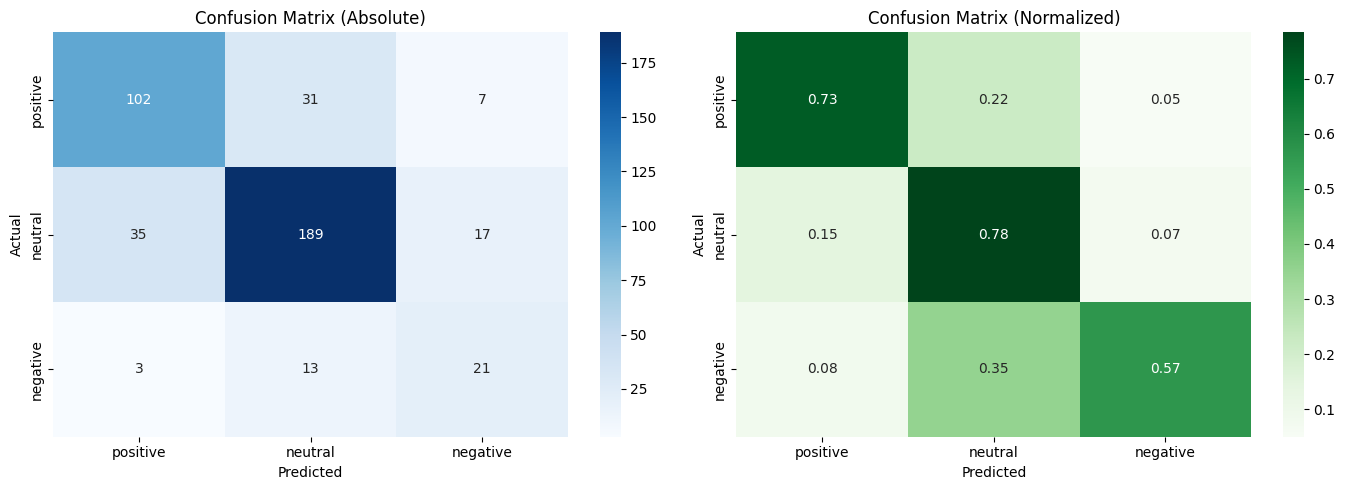

✅ Saved: confusion_matrix_phobert.png


In [ ]:
# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Confusion Matrix (Absolute)')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# Normalized
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrix_phobert.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: confusion_matrix_phobert.png')

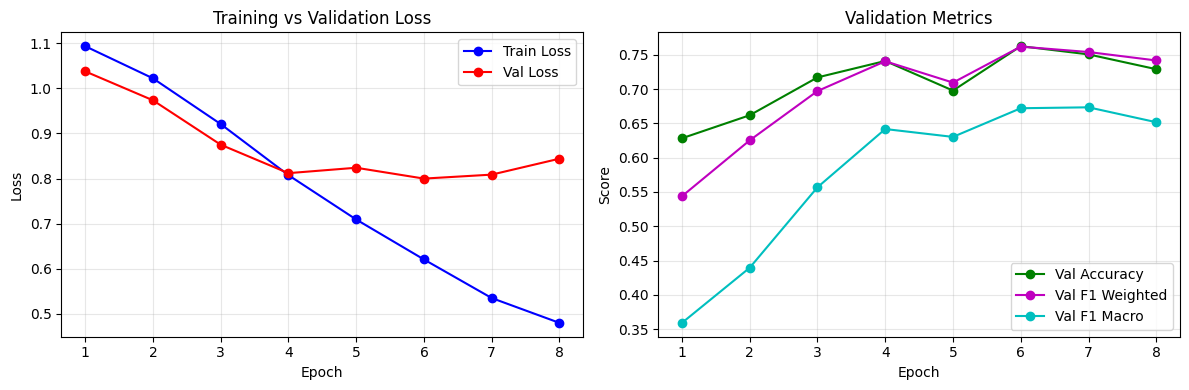

✅ Saved: training_history_phobert.png


In [ ]:
# Training history plot
hist_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist_df['epoch'], hist_df['train_loss'], 'b-o', label='Train Loss')
axes[0].plot(hist_df['epoch'], hist_df['val_loss'],   'r-o', label='Val Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(hist_df['epoch'], hist_df['val_acc'], 'g-o', label='Val Accuracy')
axes[1].plot(hist_df['epoch'], hist_df['val_f1_weighted'], 'm-o', label='Val F1 Weighted')
axes[1].plot(hist_df['epoch'], hist_df['val_f1_macro'], 'c-o', label='Val F1 Macro')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Score')
axes[1].set_title('Validation Metrics')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_phobert.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: training_history_phobert.png')

## Bước 8 — Test comment mới

In [ ]:
def predict_sentiment(text: str, model=model, tokenizer=tokenizer, device=DEVICE) -> dict:
    """Dự đoán sentiment cho một comment mới."""
    model.eval()
    clean = preprocess_text(text)
    encoding = tokenizer(
        clean,
        add_special_tokens=True,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    with torch.no_grad():
        outputs = model(
            input_ids=encoding['input_ids'].to(device),
            attention_mask=encoding['attention_mask'].to(device)
        )
    probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]
    pred_label = int(probs.argmax())
    label_names = ['positive', 'neutral', 'negative']
    return {
        'text': text,
        'text_clean': clean,
        'sentiment': label_names[pred_label],
        'confidence': float(probs[pred_label]),
        'scores': {
            'positive': float(probs[0]),
            'neutral':  float(probs[1]),
            'negative': float(probs[2])
        }
    }

# Test các comment
test_comments = [
    'Trường đẹp lắm, học phí hợp lý, thầy cô nhiệt tình 👍',
    'k thích ktx lắm, phòng chật và nóng',
    'bình thường thôi, cũng được',
    'Trường hay wáaaaa 🔥 sv TVU cảm ơn 🙏',
    'Học phí tăng mà chất lượng không tăng, thất vọng quá 😡',
]

print('=' * 60)
for comment in test_comments:
    result = predict_sentiment(comment)
    emoji = '😊' if result['sentiment'] == 'positive' else ('😐' if result['sentiment'] == 'neutral' else '😞')
    print(f'{emoji} [{result["sentiment"]:8s}] {result["confidence"]:.0%} | {comment[:50]}')
    print(f'   Scores: pos={result["scores"]["positive"]:.2f} | neu={result["scores"]["neutral"]:.2f} | neg={result["scores"]["negative"]:.2f}')
    print()

😊 [positive] 95% | Trường đẹp lắm, học phí hợp lý, thầy cô nhiệt tình
   Scores: pos=0.95 | neu=0.02 | neg=0.02

😞 [negative] 92% | k thích ktx lắm, phòng chật và nóng
   Scores: pos=0.04 | neu=0.04 | neg=0.92

😊 [positive] 71% | bình thường thôi, cũng được
   Scores: pos=0.71 | neu=0.06 | neg=0.23

😊 [positive] 96% | Trường hay wáaaaa 🔥 sv TVU cảm ơn 🙏
   Scores: pos=0.96 | neu=0.03 | neg=0.02

😞 [negative] 88% | Học phí tăng mà chất lượng không tăng, thất vọng q
   Scores: pos=0.05 | neu=0.07 | neg=0.88



## Bước 9 — Lưu model và tải về

In [22]:
import os
import json as json_lib

MODEL_SAVE_PATH = './phobert_tvu_sentiment'
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

# Lưu model + tokenizer
model.save_pretrained(MODEL_SAVE_PATH)
tokenizer.save_pretrained(MODEL_SAVE_PATH)

# Lưu metadata (bao gồm thông tin nguồn dữ liệu + benchmark)
metadata = {
    'model_name': MODEL_NAME,
    'fine_tuned_on': os.path.basename(DATA_PATH),
    'train_sources': globals().get('TRAIN_SOURCES', ['manual']),
    'num_labels': NUM_LABELS,
    'label_map': {'positive': 0, 'neutral': 1, 'negative': 2},
    'max_len': MAX_LEN,
    'epochs': EPOCHS,
    'best_val_macro_f1': float(best_val_macro_f1),
    'test_accuracy': float(test_acc),
    'test_f1_weighted': float(test_f1_weighted),
    'test_f1_macro': float(test_f1_macro),
    'train_size': len(X_train),
    'val_size': len(X_val),
    'test_size': len(X_test),
}

if 'HOLDOUT_TEST_METRICS' in globals():
    metadata['holdout_test_metrics'] = HOLDOUT_TEST_METRICS
if 'MANUAL_BENCHMARK_METRICS' in globals():
    metadata['manual_benchmark_metrics'] = MANUAL_BENCHMARK_METRICS

metadata['reporting_note'] = (
    'Hold-out test metrics dùng cho phần huấn luyện; '
    'manual benchmark metrics dùng để so sánh giống dashboard.'
)

with open(os.path.join(MODEL_SAVE_PATH, 'training_metadata.json'), 'w', encoding='utf-8') as f:
    json_lib.dump(metadata, f, ensure_ascii=False, indent=2)

print(f'✅ Model saved to {MODEL_SAVE_PATH}/')
print(f'   train_sources = {metadata["train_sources"]}')
print(f'   train_size    = {metadata["train_size"]}')
print(f'   test_accuracy = {metadata["test_accuracy"]:.4f}')
print(f'   test_f1_macro = {metadata["test_f1_macro"]:.4f}')
if 'manual_benchmark_metrics' in metadata:
    mb = metadata['manual_benchmark_metrics']
    print(
        f"   manual_benchmark = acc {mb['accuracy']:.4f}, "
        f"f1w {mb['f1_weighted']:.4f}, f1m {mb['f1_macro']:.4f}, n={mb['support']}"
    )
print(f'Files: {os.listdir(MODEL_SAVE_PATH)}')

# Nếu chạy local: copy sang models/ để dashboard dùng ngay
def _is_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False

if not _is_colab():
    import shutil
    # Tìm thư mục models/ của project
    _candidates_models = [
        os.path.join(os.path.dirname(os.path.abspath(DATA_PATH)), '..', 'models'),
        os.path.join(os.getcwd(), 'models'),
        r'D:\Thuc_tap\tiktok_analytics\models',
    ]
    _local_models = None
    for _c in _candidates_models:
        _c = os.path.normpath(_c)
        if os.path.isdir(_c):
            _local_models = _c
            break
    if _local_models is None:
        _local_models = os.path.join(os.getcwd(), 'models')
        os.makedirs(_local_models, exist_ok=True)

    # Copy từng file sang models/
    for _fname in os.listdir(MODEL_SAVE_PATH):
        _src = os.path.join(MODEL_SAVE_PATH, _fname)
        _dst = os.path.join(_local_models, _fname)
        shutil.copy2(_src, _dst)
    print(f'\n📁 Đã sao chép model sang: {_local_models}')
    print('   Dashboard sẽ tự nhận model mới sau khi restart Streamlit.')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved to ./phobert_tvu_sentiment/
   train_sources = ['manual']
   train_size    = 1402
   test_accuracy = 0.7243
   test_f1_macro = 0.5418
   manual_benchmark = acc 0.7829, f1w 0.7766, f1m 0.7470, n=2004
Files: ['added_tokens.json', 'bpe.codes', 'config.json', 'model.safetensors', 'tokenizer_config.json', 'training_metadata.json', 'vocab.txt']

📁 Đã sao chép model sang: d:\Thuc_tap\tiktok_analytics\models
   Dashboard sẽ tự nhận model mới sau khi restart Streamlit.


In [ ]:

# Nén thành ZIP và tải về máy tính
import shutil

shutil.make_archive('phobert_tvu_sentiment', 'zip', MODEL_SAVE_PATH)
zip_size = os.path.getsize('phobert_tvu_sentiment.zip') / 1e6
print(f'✅ Compressed: phobert_tvu_sentiment.zip ({zip_size:.1f} MB)')

def _is_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False

if _is_colab():
    from google.colab import files
    files.download('phobert_tvu_sentiment.zip')
    files.download('confusion_matrix_phobert.png')
    files.download('training_history_phobert.png')
    print('📥 Đang tải file về máy...')
else:
    import pathlib
    cwd = pathlib.Path('.').resolve()
    print('\n📂 Chạy local — file đã lưu tại:')
    print(f'  Model ZIP : {cwd / "phobert_tvu_sentiment.zip"}')
    if (cwd / 'confusion_matrix_phobert.png').exists():
        print(f'  Confusion  : {cwd / "confusion_matrix_phobert.png"}')
    if (cwd / 'training_history_phobert.png').exists():
        print(f'  History    : {cwd / "training_history_phobert.png"}')
    print('\n👉 Copy thư mục phobert_tvu_sentiment/ vào tiktok_analytics/models/')


✅ Compressed: phobert_tvu_sentiment.zip (446.4 MB)

📂 Chạy local — file đã lưu tại:
  Model ZIP : D:\Thuc_tap\tiktok_analytics\phobert_tvu_sentiment.zip
  Confusion  : D:\Thuc_tap\tiktok_analytics\confusion_matrix_phobert.png
  History    : D:\Thuc_tap\tiktok_analytics\training_history_phobert.png

👉 Copy thư mục phobert_tvu_sentiment/ vào tiktok_analytics/models/


## Bước 10 — Code tích hợp Streamlit (copy/paste)

Sau khi tải `phobert_tvu_sentiment.zip` về, giải nén vào thư mục:
```
tiktok_analytics/
  models/
    phobert_tvu_sentiment/     ← giải nén vào đây
      config.json
      model.safetensors
      tokenizer_config.json
      vocab.txt
      ...
```

Sau đó dùng module `modules/phobert_sentiment.py` đã có sẵn trong project.

In [ ]:
# ── CODE MẪU TÍCH HỢP STREAMLIT ──
# Copy đoạn code này vào modules/phobert_sentiment.py trong project

INTEGRATION_CODE = '''
# modules/phobert_sentiment.py
# Sử dụng trong dashboard.py:
#   from modules.phobert_sentiment import PhoBERTSentiment
#   analyzer = PhoBERTSentiment(model_path="models/phobert_tvu_sentiment")
#   result = analyzer.predict("k thích ktx lắm")

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

class PhoBERTSentiment:
    def __init__(self, model_path="models/phobert_tvu_sentiment"):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.tokenizer = AutoTokenizer.from_pretrained(model_path)
        self.model = AutoModelForSequenceClassification.from_pretrained(model_path)
        self.model = self.model.to(self.device)
        self.model.eval()

    def predict(self, text: str) -> dict:
        enc = self.tokenizer(
            text, return_tensors="pt", truncation=True,
            max_length=128, padding="max_length"
        )
        with torch.no_grad():
            logits = self.model(**{k: v.to(self.device) for k, v in enc.items()}).logits
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
        labels = ["positive", "neutral", "negative"]
        idx = probs.argmax()
        return {"sentiment": labels[idx], "confidence": float(probs[idx]),
                "scores": dict(zip(labels, probs.tolist()))}
'''
print(INTEGRATION_CODE)


# modules/phobert_sentiment.py
# Sử dụng trong dashboard.py:
#   from modules.phobert_sentiment import PhoBERTSentiment
#   analyzer = PhoBERTSentiment(model_path="models/phobert_tvu_sentiment")
#   result = analyzer.predict("k thích ktx lắm")

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

class PhoBERTSentiment:
    def __init__(self, model_path="models/phobert_tvu_sentiment"):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.tokenizer = AutoTokenizer.from_pretrained(model_path)
        self.model = AutoModelForSequenceClassification.from_pretrained(model_path)
        self.model = self.model.to(self.device)
        self.model.eval()

    def predict(self, text: str) -> dict:
        enc = self.tokenizer(
            text, return_tensors="pt", truncation=True,
            max_length=128, padding="max_length"
        )
        with torch.no_grad():
            logits = self.model(**{k: v.to(self.

---
## 🎯 Tổng kết

| Metric | Score |
|--------|-------|
| **Test Accuracy** | Xem kết quả Bước 7 |
| **Test F1** | Xem kết quả Bước 7 |
| **Best Val F1** | Xem kết quả Bước 6 |

**File đã tải về:**
- `phobert_tvu_sentiment.zip` — Model fine-tuned (giải nén vào `tiktok_analytics/models/`)
- `confusion_matrix_phobert.png`
- `training_history_phobert.png`

**Bước tiếp theo:**
1. Giải nén model vào `tiktok_analytics/models/phobert_tvu_sentiment/`
2. Chạy Streamlit: `streamlit run dashboard.py`
3. Trang **🔬 Đánh giá Gemini** tự động khi có model